# Домашнее задание HW12: Временные ряды

## Прогнозирование временного ряда с помощью baselines и GRU

In [4]:
# 1. Импорты, seed, устройство
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Фиксация seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Папки для артефактов
artifacts_dir = './artifacts'
figures_dir = os.path.join(artifacts_dir, 'figures')
os.makedirs(artifacts_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

Using device: cuda


## 1. Загрузка и первичный анализ данных

Размер данных: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Пропуски:
date      0
target    0
dtype: int64


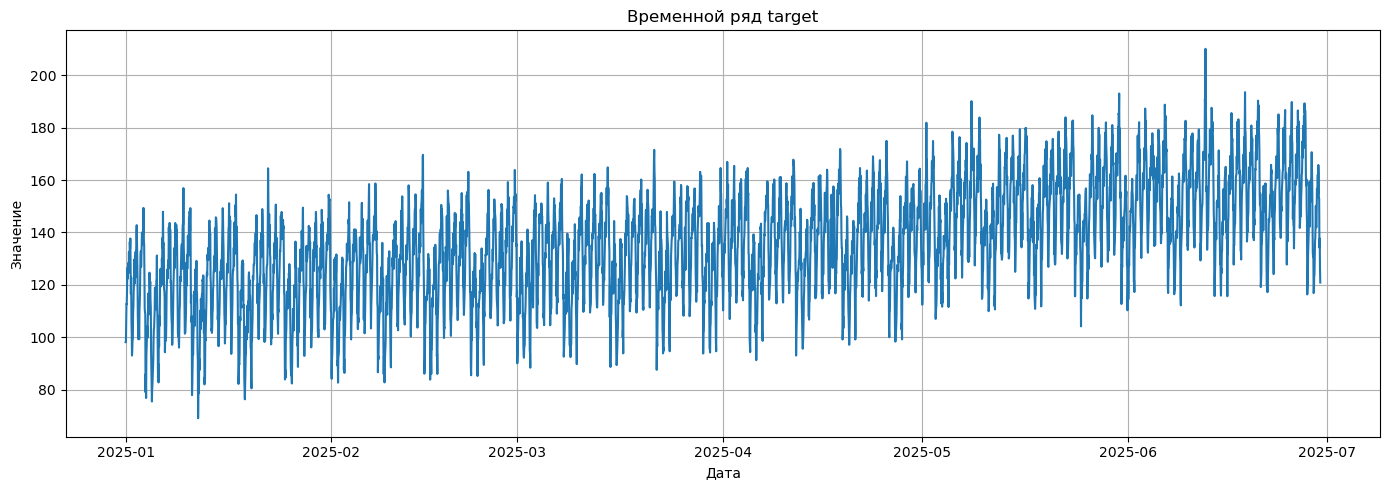

Ряд имеет ярко выраженную суточную сезонность, возможно, недельную.
Виден общий восходящий тренд в конце периода, но в начале и середине он нестабилен.


In [5]:
# Загрузка данных
df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Проверка пропусков
print(f"Размер данных: {df.shape}")
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"Пропуски:\n{df.isnull().sum()}")

# График ряда
plt.figure(figsize=(14,5))
plt.plot(df['date'], df['target'])
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'series_full.png'))
plt.show()

# Комментарий
print("Ряд имеет ярко выраженную суточную сезонность, возможно, недельную.")
print("Виден общий восходящий тренд в конце периода, но в начале и середине он нестабилен.")

## 2. Temporal split (train / val / test)

Train: 2025-01-01 00:00:00 - 2025-05-06 23:00:00 (3024 записей)
Val:   2025-05-07 00:00:00 - 2025-06-02 23:00:00 (648 записей)
Test:  2025-06-03 00:00:00 - 2025-06-29 23:00:00 (648 записей)


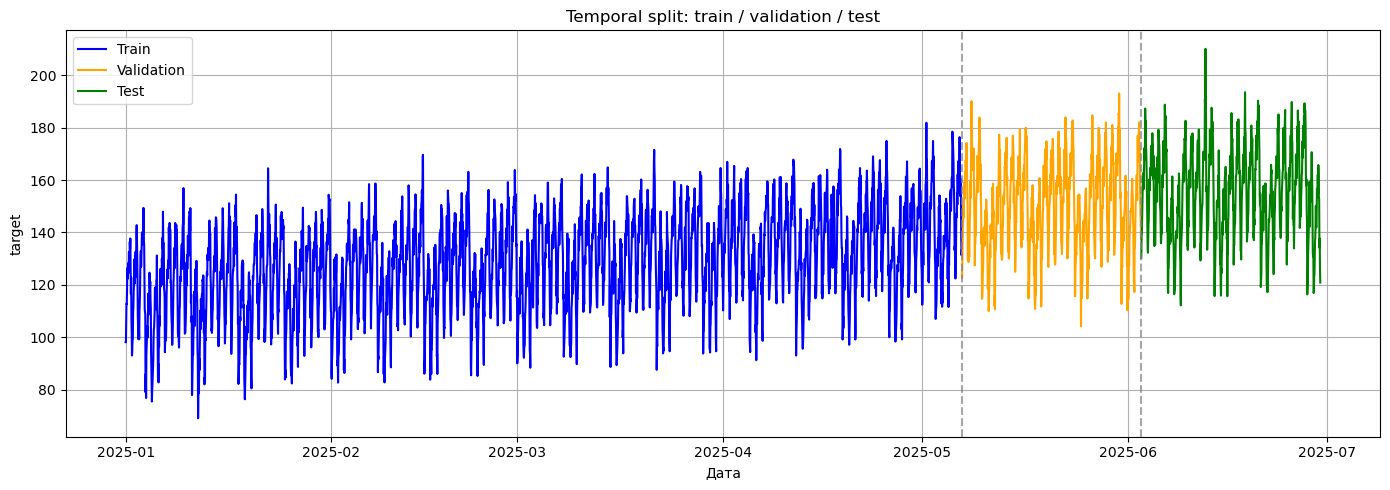


Почему random split некорректен: временные ряды имеют автокорреляцию и сезонность.
Перемешивание нарушило бы временную структуру, и модель могла бы использовать будущие данные.


In [6]:
# Разделение по времени (без перемешивания)
total = len(df)
train_end = int(total * 0.7)
val_end = int(total * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train: {train_df['date'].min()} - {train_df['date'].max()} ({len(train_df)} записей)")
print(f"Val:   {val_df['date'].min()} - {val_df['date'].max()} ({len(val_df)} записей)")
print(f"Test:  {test_df['date'].min()} - {test_df['date'].max()} ({len(test_df)} записей)")

# Визуализация разделения
plt.figure(figsize=(14,5))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue')
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange')
plt.plot(test_df['date'], test_df['target'], label='Test', color='green')
plt.axvline(x=train_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=val_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.7)
plt.legend()
plt.title('Temporal split: train / validation / test')
plt.xlabel('Дата')
plt.ylabel('target')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'series_split.png'))
plt.show()

# Объяснение
print("\nПочему random split некорректен: временные ряды имеют автокорреляцию и сезонность.")
print("Перемешивание нарушило бы временную структуру, и модель могла бы использовать будущие данные.")

## 3. Построение признаков для B3 (Ridge)

In [7]:
def create_lag_features(df, lags=[1,7,14], windows=[7]):
    df = df.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df['target'].shift(lag)
    for w in windows:
        df[f'rolling_mean_{w}'] = df['target'].shift(1).rolling(w).mean()
        df[f'rolling_std_{w}'] = df['target'].shift(1).rolling(w).std()
    df['day_of_week'] = df['date'].dt.dayofweek
    df['hour'] = df['date'].dt.hour
    # удаляем строки с NaN, возникшими из-за сдвигов
    df = df.dropna().reset_index(drop=True)
    return df

# Применяем к train, val, test отдельно, чтобы избежать утечки
train_feat = create_lag_features(train_df)
val_feat = create_lag_features(val_df)
test_feat = create_lag_features(test_df)

# Целевая переменная
target_col = 'target'
feature_cols = [col for col in train_feat.columns if col not in ['date', target_col]]

X_train = train_feat[feature_cols].values
y_train = train_feat[target_col].values
X_val = val_feat[feature_cols].values
y_val = val_feat[target_col].values
X_test = test_feat[feature_cols].values
y_test = test_feat[target_col].values

# Масштабирование (обучаем только на train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Количество признаков: {len(feature_cols)}")
print(f"Признаки: {feature_cols}")

Количество признаков: 7
Признаки: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'hour']


## 4. Базовые эксперименты (B1, B2, B3)

In [8]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE с защитой от нуля
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

# B1: naive-last (прогноз = предыдущее значение)
# Для этого нужно сдвинуть y_val на 1, но так как у нас уже есть лаги, используем lag_1 из train_feat
# Но для валидации надо сгенерировать прогнозы последовательно. Проще: прогноз = предыдущее истинное значение.
# В валидации мы знаем истинные значения, поэтому для B1 просто предсказываем предыдущее значение.
y_pred_b1_val = val_feat['lag_1'].values
y_pred_b1_test = test_feat['lag_1'].values
mae_b1_val, rmse_b1_val, mape_b1_val = evaluate(y_val, y_pred_b1_val)
mae_b1_test, rmse_b1_test, mape_b1_test = evaluate(y_test, y_pred_b1_test)

# B2: moving-average (окно 24 часа – суточная сезонность)
# Используем скользящее среднее за 24 предыдущих часа
window_ma = 24
y_pred_b2_val = val_feat['rolling_mean_7'].values  # заменим на rolling_mean_24, создадим отдельно
# Создадим признак rolling_mean_24 для B2
def add_rolling_24(df):
    df = df.copy()
    df['rolling_mean_24'] = df['target'].shift(1).rolling(24).mean()
    return df
train_b2 = add_rolling_24(train_df).dropna()
val_b2 = add_rolling_24(val_df).dropna()
test_b2 = add_rolling_24(test_df).dropna()
y_pred_b2_val = val_b2['rolling_mean_24'].values
y_pred_b2_test = test_b2['rolling_mean_24'].values
y_val_b2 = val_b2['target'].values
y_test_b2 = test_b2['target'].values
mae_b2_val, rmse_b2_val, mape_b2_val = evaluate(y_val_b2, y_pred_b2_val)
mae_b2_test, rmse_b2_test, mape_b2_test = evaluate(y_test_b2, y_pred_b2_test)

# B3: Ridge на признаках
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_b3_val = ridge.predict(X_val_scaled)
y_pred_b3_test = ridge.predict(X_test_scaled)
mae_b3_val, rmse_b3_val, mape_b3_val = evaluate(y_val, y_pred_b3_val)
mae_b3_test, rmse_b3_test, mape_b3_test = evaluate(y_test, y_pred_b3_test)

print("=== B1 (naive-last) ===")
print(f"Val: MAE={mae_b1_val:.3f}, RMSE={rmse_b1_val:.3f}, MAPE={mape_b1_val:.2f}%")
print(f"Test: MAE={mae_b1_test:.3f}, RMSE={rmse_b1_test:.3f}, MAPE={mape_b1_test:.2f}%")
print("\n=== B2 (moving-average, window=24) ===")
print(f"Val: MAE={mae_b2_val:.3f}, RMSE={rmse_b2_val:.3f}, MAPE={mape_b2_val:.2f}%")
print(f"Test: MAE={mae_b2_test:.3f}, RMSE={rmse_b2_test:.3f}, MAPE={mape_b2_test:.2f}%")
print("\n=== B3 (Ridge) ===")
print(f"Val: MAE={mae_b3_val:.3f}, RMSE={rmse_b3_val:.3f}, MAPE={mape_b3_val:.2f}%")
print(f"Test: MAE={mae_b3_test:.3f}, RMSE={rmse_b3_test:.3f}, MAPE={mape_b3_test:.2f}%")

=== B1 (naive-last) ===
Val: MAE=6.461, RMSE=8.241, MAPE=4.41%
Test: MAE=6.378, RMSE=8.110, MAPE=4.17%

=== B2 (moving-average, window=24) ===
Val: MAE=13.437, RMSE=16.228, MAPE=9.23%
Test: MAE=13.166, RMSE=16.151, MAPE=8.77%

=== B3 (Ridge) ===
Val: MAE=6.381, RMSE=7.918, MAPE=4.29%
Test: MAE=6.321, RMSE=8.034, MAPE=4.07%


## 5. Подготовка данных для GRU (оконное представление)

In [9]:
# Выбираем window_size (используем 24, чтобы захватить суточную сезонность)
window_size = 24

class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = data
        self.window_size = window_size
    def __len__(self):
        return len(self.data) - self.window_size
    def __getitem__(self, idx):
        x = self.data[idx:idx+self.window_size]
        y = self.data[idx+self.window_size]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# Масштабирование таргета на train
scaler_target = StandardScaler()
train_target_scaled = scaler_target.fit_transform(train_df['target'].values.reshape(-1,1)).flatten()
val_target_scaled = scaler_target.transform(val_df['target'].values.reshape(-1,1)).flatten()
test_target_scaled = scaler_target.transform(test_df['target'].values.reshape(-1,1)).flatten()

# Создаём датасеты
train_dataset = TimeSeriesDataset(train_target_scaled, window_size)
val_dataset = TimeSeriesDataset(val_target_scaled, window_size)
test_dataset = TimeSeriesDataset(test_target_scaled, window_size)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## 6. Модель GRU и обучение

Epoch 10/100 - Train Loss: 0.117028, Val Loss: 0.201700
Epoch 20/100 - Train Loss: 0.100602, Val Loss: 0.193797
Epoch 30/100 - Train Loss: 0.098397, Val Loss: 0.185010
Epoch 40/100 - Train Loss: 0.098841, Val Loss: 0.183226
Epoch 50/100 - Train Loss: 0.099266, Val Loss: 0.182621
Epoch 60/100 - Train Loss: 0.098167, Val Loss: 0.182315
Epoch 70/100 - Train Loss: 0.097775, Val Loss: 0.182152
Epoch 80/100 - Train Loss: 0.098386, Val Loss: 0.182067
Epoch 90/100 - Train Loss: 0.098193, Val Loss: 0.182070
Epoch 100/100 - Train Loss: 0.098643, Val Loss: 0.182068
Лучшая модель сохранена


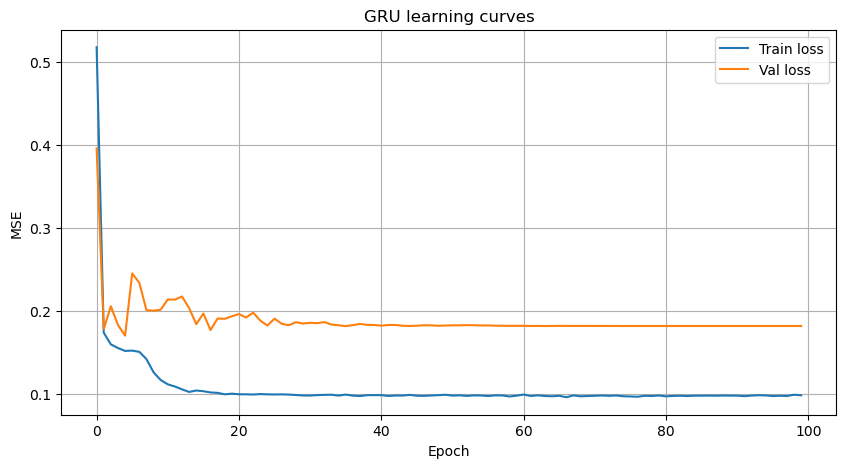

In [10]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]  # берём последний выход
        return self.fc(out)

model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

num_epochs = 100
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.unsqueeze(-1).to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.unsqueeze(-1).to(device), y.to(device)
            y_pred = model(x)
            loss = criterion(y_pred, y)
            val_loss += loss.item() * x.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

# Сохраняем лучшую модель
torch.save(best_model_state, os.path.join(artifacts_dir, 'best_gru.pt'))
print("Лучшая модель сохранена")

# График обучения
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('GRU learning curves')
plt.grid(True)
plt.savefig(os.path.join(figures_dir, 'gru_learning_curves.png'))
plt.show()

In [11]:
# Оценка GRU на валидации и тесте
def evaluate_gru(model, loader, scaler):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x, y in loader:
            x = x.unsqueeze(-1).to(device)
            pred = model(x).cpu().numpy()
            y_true.append(y.numpy())
            y_pred.append(pred)
    y_true = np.concatenate(y_true).reshape(-1,1)
    y_pred = np.concatenate(y_pred).reshape(-1,1)
    y_true = scaler.inverse_transform(y_true).flatten()
    y_pred = scaler.inverse_transform(y_pred).flatten()
    return y_true, y_pred

# Загружаем лучшую модель
model.load_state_dict(best_model_state)
y_val_true, y_val_pred = evaluate_gru(model, val_loader, scaler_target)
y_test_true, y_test_pred = evaluate_gru(model, test_loader, scaler_target)

mae_gru_val, rmse_gru_val, mape_gru_val = evaluate(y_val_true, y_val_pred)
mae_gru_test, rmse_gru_test, mape_gru_test = evaluate(y_test_true, y_test_pred)

print("=== GRU ===")
print(f"Val: MAE={mae_gru_val:.3f}, RMSE={rmse_gru_val:.3f}, MAPE={mape_gru_val:.2f}%")
print(f"Test: MAE={mae_gru_test:.3f}, RMSE={rmse_gru_test:.3f}, MAPE={mape_gru_test:.2f}%")

=== GRU ===
Val: MAE=6.160, RMSE=7.886, MAPE=4.11%
Test: MAE=7.676, RMSE=9.605, MAPE=4.89%


## 7. Сохранение результатов и конфига

In [13]:
# Формирование runs.csv
runs = []

# B1
runs.append({
    'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw', 'seed': 42,
    'split_summary': '70/15/15', 'window_size': None, 'horizon': 1,
    'model_summary': 'naive_last', 'features_summary': 'lag_1', 'scaler': None,
    'optimizer': None, 'lr': None, 'epochs_trained': None,
    'best_val_mae': mae_b1_val, 'best_val_rmse': rmse_b1_val, 'best_val_mape': mape_b1_val,
    'test_mae': mae_b1_test, 'test_rmse': rmse_b1_test, 'test_mape': mape_b1_test,
    'notes': ''
})

# B2
runs.append({
    'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw', 'seed': 42,
    'split_summary': '70/15/15', 'window_size': 24, 'horizon': 1,
    'model_summary': 'moving_average', 'features_summary': 'rolling_mean_24', 'scaler': None,
    'optimizer': None, 'lr': None, 'epochs_trained': None,
    'best_val_mae': mae_b2_val, 'best_val_rmse': rmse_b2_val, 'best_val_mape': mape_b2_val,
    'test_mae': mae_b2_test, 'test_rmse': rmse_b2_test, 'test_mape': mape_b2_test,
    'notes': 'window=24'
})

# B3
runs.append({
    'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12-hw', 'seed': 42,
    'split_summary': '70/15/15', 'window_size': None, 'horizon': 1,
    'model_summary': 'Ridge', 'features_summary': 'lags+rolling+calendar', 'scaler': 'StandardScaler',
    'optimizer': None, 'lr': None, 'epochs_trained': None,
    'best_val_mae': mae_b3_val, 'best_val_rmse': rmse_b3_val, 'best_val_mape': mape_b3_val,
    'test_mae': mae_b3_test, 'test_rmse': rmse_b3_test, 'test_mape': mape_b3_test,
    'notes': ''
})

# R1
runs.append({
    'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12-hw', 'seed': 42,
    'split_summary': '70/15/15', 'window_size': window_size, 'horizon': 1,
    'model_summary': 'GRU (2 layers, 64 hidden)', 'features_summary': 'target only', 'scaler': 'StandardScaler',
    'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': num_epochs,
    'best_val_mae': mae_gru_val, 'best_val_rmse': rmse_gru_val, 'best_val_mape': mape_gru_val,
    'test_mae': mae_gru_test, 'test_rmse': rmse_gru_test, 'test_mape': mape_gru_test,
    'notes': ''
})

runs_df = pd.DataFrame(runs)
runs_df.to_csv(os.path.join(artifacts_dir, 'runs.csv'), index=False)

# Конфиг лучшей GRU (преобразуем numpy.float32 в float)
config = {
    'experiment_id': 'R1',
    'architecture': 'GRU',
    'window_size': int(window_size),
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.2,
    'batch_size': int(batch_size),
    'learning_rate': 0.001,
    'optimizer': 'Adam',
    'epochs': int(num_epochs),
    'seed': 42,
    'scaler': 'StandardScaler',
    'best_val_mae': float(mae_gru_val),
    'best_val_rmse': float(rmse_gru_val),
    'best_val_mape': float(mape_gru_val)
}

import json
with open(os.path.join(artifacts_dir, 'best_gru_config.json'), 'w') as f:
    json.dump(config, f, indent=4)

print("runs.csv и best_gru_config.json сохранены")

runs.csv и best_gru_config.json сохранены


## 8. Графики сравнения и прогнозов

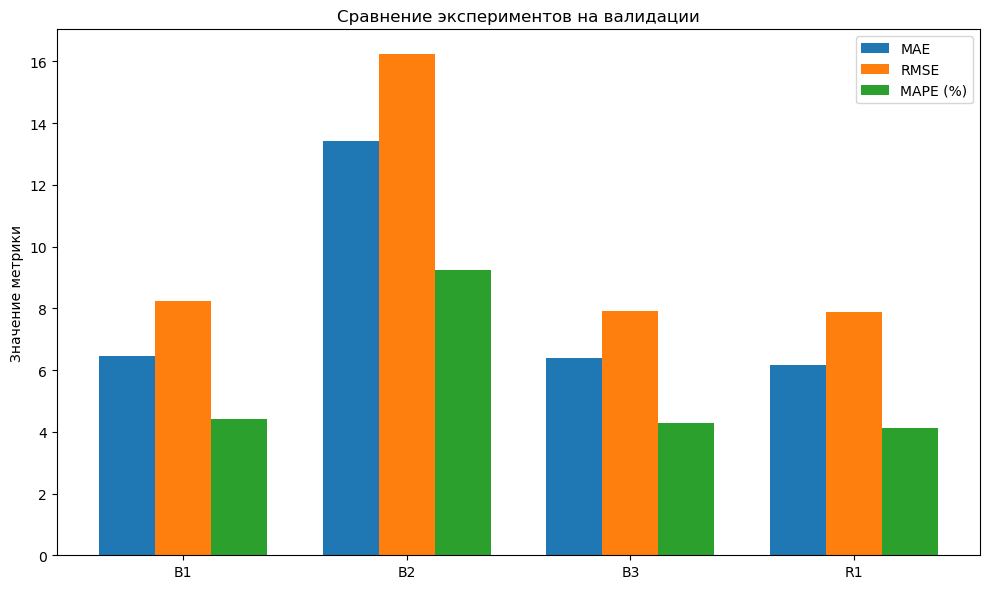

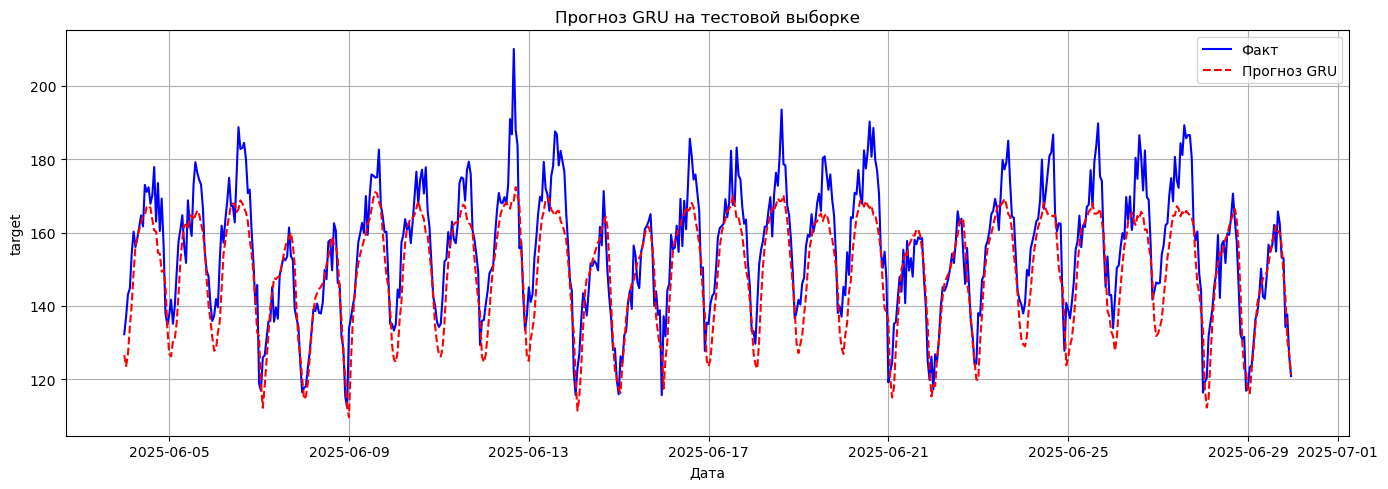

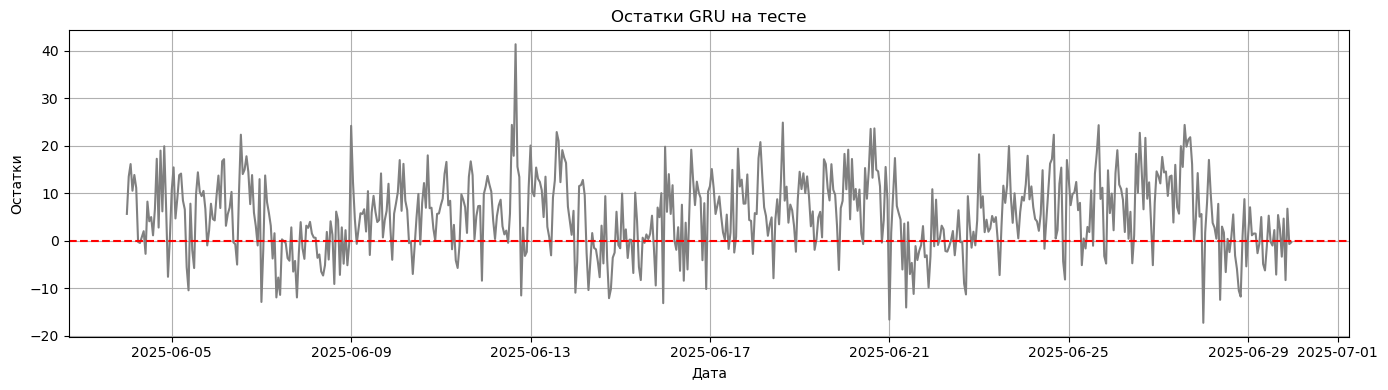

In [14]:
# Сравнение baselines
fig, ax = plt.subplots(figsize=(10,6))
models = ['B1', 'B2', 'B3', 'R1']
mae_vals = [mae_b1_val, mae_b2_val, mae_b3_val, mae_gru_val]
rmse_vals = [rmse_b1_val, rmse_b2_val, rmse_b3_val, rmse_gru_val]
mape_vals = [mape_b1_val, mape_b2_val, mape_b3_val, mape_gru_val]

x = np.arange(len(models))
width = 0.25
ax.bar(x - width, mae_vals, width, label='MAE')
ax.bar(x, rmse_vals, width, label='RMSE')
ax.bar(x + width, mape_vals, width, label='MAPE (%)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение экспериментов на валидации')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'baselines_compare.png'))
plt.show()

# График прогноза лучшей модели на тесте
plt.figure(figsize=(14,5))
plt.plot(test_df['date'].iloc[window_size:], y_test_true, label='Факт', color='blue')
plt.plot(test_df['date'].iloc[window_size:], y_test_pred, label='Прогноз GRU', color='red', linestyle='--')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.title('Прогноз GRU на тестовой выборке')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'best_forecast_test.png'))
plt.show()

# Дополнительно: график остатков
residuals = y_test_true - y_test_pred
plt.figure(figsize=(14,4))
plt.plot(test_df['date'].iloc[window_size:], residuals, color='gray')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Дата')
plt.ylabel('Остатки')
plt.title('Остатки GRU на тесте')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'residuals_best.png'))
plt.show()